# Очистка чертежа: классификация штрихов и поиск наконечников

| шаг | что делает | результат |
|---|---|---|
| 1 | загрузка, единый масштаб | `img_bgr` |
| 2 | детекция текста (PP-OCRv5 det) | `text_region` |
| 3 | бинаризация | `strokes` |
| 4 | граф скелета, толщина ребра, доля текста | `graph` |
| 5 | склейка ребер в цепи | `chains` |
| 6 | классы толщины, KMeans без текста | `classes` |
| 7 | перерисовка сохраненных линий | `clean_mask` |

Текст ищется не ради текста, а чтобы буквы не смещали распределение толщин, по которому KMeans
ставит границы классов. Поэтому граф строится до кластеризации: чистить выборку надо целыми
ребрами, а не пикселями внутри прямоугольника.

Соглашения кода:
- данные шага живут в неизменяемом датаклассе, а не в словаре и не в DataFrame;
- DataFrame используется только внутри `report_*` для печати;
- `run_*` ничего не вычисляет, только вызывает чистые функции, отчет и отрисовку;
- параметры подбираются слайдерами, результат лежит в `ui_*.result`.

## 0. Импорты и типы

In [1]:
from dataclasses import dataclass
from itertools import combinations
from pathlib import Path

import cv2
import numpy as np
import numpy.typing as npt
import pandas as pd
from ipywidgets import Checkbox, Dropdown, FloatSlider, IntSlider, interactive
from matplotlib import pyplot as plt
from matplotlib.axes import Axes
from matplotlib.collections import LineCollection
from scipy.sparse import coo_matrix
from scipy.sparse.csgraph import connected_components
from scipy.spatial import cKDTree
from skan import Skeleton, summarize
from skimage.morphology import skeletonize
from sklearn.cluster import KMeans

Img = npt.NDArray[np.uint8]  # BGR или одноканальная картинка
Mask = npt.NDArray[np.bool_]
Floats = npt.NDArray[np.float64]
Ints = npt.NDArray[np.int64]
Window = tuple[float, float, float, float]  # x0, x1, y0, y1

PALETTE: tuple[tuple[int, int, int], ...] = (
    (70, 130, 255),
    (60, 200, 90),
    (255, 190, 40),
    (255, 70, 70),
    (200, 80, 255),
    (0, 220, 220),
)
SCALE: float = 2.0  # единственный ресайз после детекции текста
TEXT_LIMIT: float = 0.5  # доля пикселей в маске, выше которой объект считается текстом

## 1. Загрузка и масштаб

Длинная сторона приводится к единому размеру, это единственный ресайз пайплайна. Вверх бикубикой:
она восстанавливает по серой кайме вокруг штриха плавный градиент, порог режет край субпиксельно,
и толщины перестают слипаться при квантовании distance transform. Вниз INTER_AREA.

In [2]:
def load_image(path: Path) -> Img:
    """Чтение картинки по пути с кириллицей."""
    data = np.fromfile(str(path), dtype=np.uint8)
    image = cv2.imdecode(data, cv2.IMREAD_COLOR)
    if image is None:
        raise ValueError(f"не читается: {path}")
    return image


def resize_long_side(image: Img, max_size: int) -> Img:
    """Длинная сторона -> max_size. Вверх бикубикой, вниз INTER_AREA."""
    side = max(image.shape[:2])
    if side == max_size:
        return image
    k = max_size / float(side)
    interp = cv2.INTER_AREA if k < 1 else cv2.INTER_CUBIC
    return cv2.resize(image, (round(image.shape[1] * k), round(image.shape[0] * k)), interpolation=interp)


def upscale_image(image: Img, scale: float) -> Img:
    """Увеличение с сохранением пропорций."""
    h, w = image.shape[:2]
    size = max(h, w)
    if size > 9000:
        return image
    return cv2.resize(image, (int(w * scale), int(h * scale)), interpolation=cv2.INTER_LINEAR)


def upscale_mask(mask: Mask, scale: float) -> Mask:
    """Тот же ресайз для бинарной маски."""
    return upscale_image(mask.astype(np.uint8) * 255, scale) > 0

In [3]:
def show_image(image: Img, title: str = "", figsize: tuple[float, float] = (16, 8)) -> None:
    """Показ BGR картинки."""
    plt.figure(figsize=figsize)
    plt.imshow(image[..., ::-1])
    plt.axis("off")
    plt.title(title)
    plt.show()


def show_mask(mask: Mask, title: str = "", figsize: tuple[float, float] = (16, 8)) -> None:
    """Показ бинарной маски: штрих черным на белом."""
    plt.figure(figsize=figsize)
    plt.imshow(np.where(mask, 0, 255).astype(np.uint8), cmap="gray")
    plt.axis("off")
    plt.title(title)
    plt.show()

In [4]:
FOLDER = Path("/mnt/data/datasets/Сравнение чертежей/Эскизы датасет")
files: list[Path] = sorted(FOLDER.glob("*.jpg"))

print(f"файлов: {len(files)}")

файлов: 21


In [5]:
def run_load(idx: int) -> Img:
    """Слайдер выбора файла."""
    image = load_image(files[idx])
    show_image(image, f"[{idx}] {files[idx].stem} | {image.shape[1]}x{image.shape[0]}")
    return image


ui_load = interactive(
    run_load,
    idx=Dropdown(options=[(f"[{i}] {f.stem}", i) for i, f in enumerate(files)], value=6, description="файл"),
)
ui_load

interactive(children=(Dropdown(description='файл', index=6, options=(('[0] 1', 0), ('[1] 10', 1), ('[2] 11', 2…

In [6]:
img_bgr: Img = ui_load.result
print(f"кадр {img_bgr.shape[1]}x{img_bgr.shape[0]} | {img_bgr.dtype}")

кадр 1475x919 | uint8


## 2. Детекция текста

Цель не удалить текст, а исключить его из выборки, по которой оцениваются границы классов толщины.
Поэтому маска может быть грубой: мы ничего не стираем, а только не учитываем.

DBNet требует размер, кратный 32. Добираем паддингом белым, а не ресайзом, чтобы масштаб остался
ровно 1.0 и маска легла на штрихи попиксельно.

In [7]:
@dataclass(frozen=True, eq=False)
class Padded:
    """Картинка, добитая белым до кратности stride."""

    image: Img
    rows: int
    cols: int


def pad_to_stride(image: Img, stride: int = 32) -> Padded:
    """Паддинг белым до кратности stride, масштаб остается 1.0."""
    h, w = image.shape[:2]
    rows, cols = (-h) % stride, (-w) % stride
    if rows == 0 and cols == 0:
        return Padded(image, 0, 0)
    padded = cv2.copyMakeBorder(image, 0, rows, 0, cols, cv2.BORDER_CONSTANT, value=(255, 255, 255))
    return Padded(padded, rows, cols)


def to_blob(image: Img) -> npt.NDArray[np.float32]:
    """Нормализация из PP-OCRv5_server_det.yml: scale 1/255, ImageNet mean/std."""
    rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB).astype(np.float32) / 255.0
    mean = np.array([0.485, 0.456, 0.406], dtype=np.float32)
    std = np.array([0.229, 0.224, 0.225], dtype=np.float32)
    return ((rgb - mean) / std).transpose(2, 0, 1)[np.newaxis, ...]

In [8]:
import onnxruntime as ort

det_session = ort.InferenceSession("./models/PP-OCRv5_server_det_infer.onnx")
det_input: str = det_session.get_inputs()[0].name

print(f"вход: {det_input} | {det_session.get_inputs()[0].shape}")

вход: x | ['DynamicDimension.0', 3, 'DynamicDimension.1', 'DynamicDimension.2']


In [9]:
def detect_prob(image: Img) -> Floats:
    """Одна прогонка DBNet. Карта вероятностей совпадает с image попиксельно."""
    padded = pad_to_stride(image)
    raw = det_session.run(None, {det_input: to_blob(padded.image)})[0]
    h, w = raw.shape[-2:]
    return raw[0, 0, : h - padded.rows, : w - padded.cols].astype(np.float64)


def resize_prob(prob: Floats, shape: tuple[int, int]) -> Floats:
    """Карта вероятностей в разрешение (h, w)."""
    interp = cv2.INTER_AREA if prob.shape[0] > shape[0] else cv2.INTER_LINEAR
    return cv2.resize(prob.astype(np.float32), (shape[1], shape[0]), interpolation=interp).astype(np.float64)


def multiscale_prob(image: Img, scales: tuple[int, ...]) -> Floats:
    """Стек карт с нескольких масштабов, все в разрешении image. -> (S, H, W)"""
    maps: list[Floats] = []
    for scale in scales:
        small = resize_long_side(image, scale)
        prob = resize_prob(detect_prob(small), image.shape[:2])
        print(f"масштаб {scale}: {small.shape[1]}x{small.shape[0]} | max {prob.max():.2f}")
        maps.append(prob)
    return np.stack(maps)

масштаб 320: 320x199 | max 1.00
масштаб 640: 640x399 | max 1.00
масштаб 2000: 2000x1246 | max 1.00


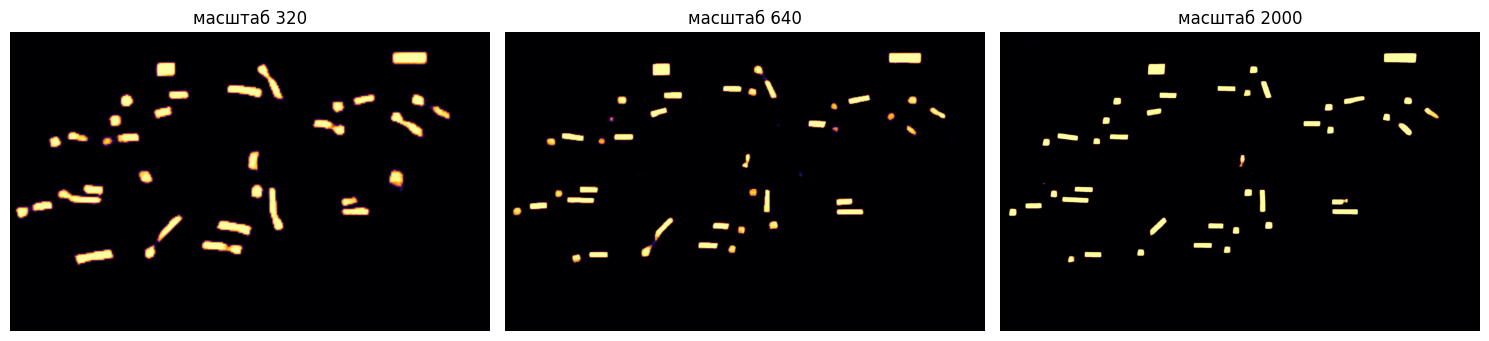

In [10]:
SCALES: tuple[int, ...] = (320, 640, 2000)
prob_stack: Floats = multiscale_prob(img_bgr, SCALES)

fig, axes = plt.subplots(1, len(SCALES), figsize=(5 * len(SCALES), 5))
for ax, prob, scale in zip(axes, prob_stack, SCALES, strict=True):
    ax.imshow(prob, cmap="inferno", vmin=0, vmax=1)
    ax.set_title(f"масштаб {scale}")
    ax.axis("off")
plt.tight_layout()
plt.show()

prob (919, 1475) | min 0.000 max 1.000


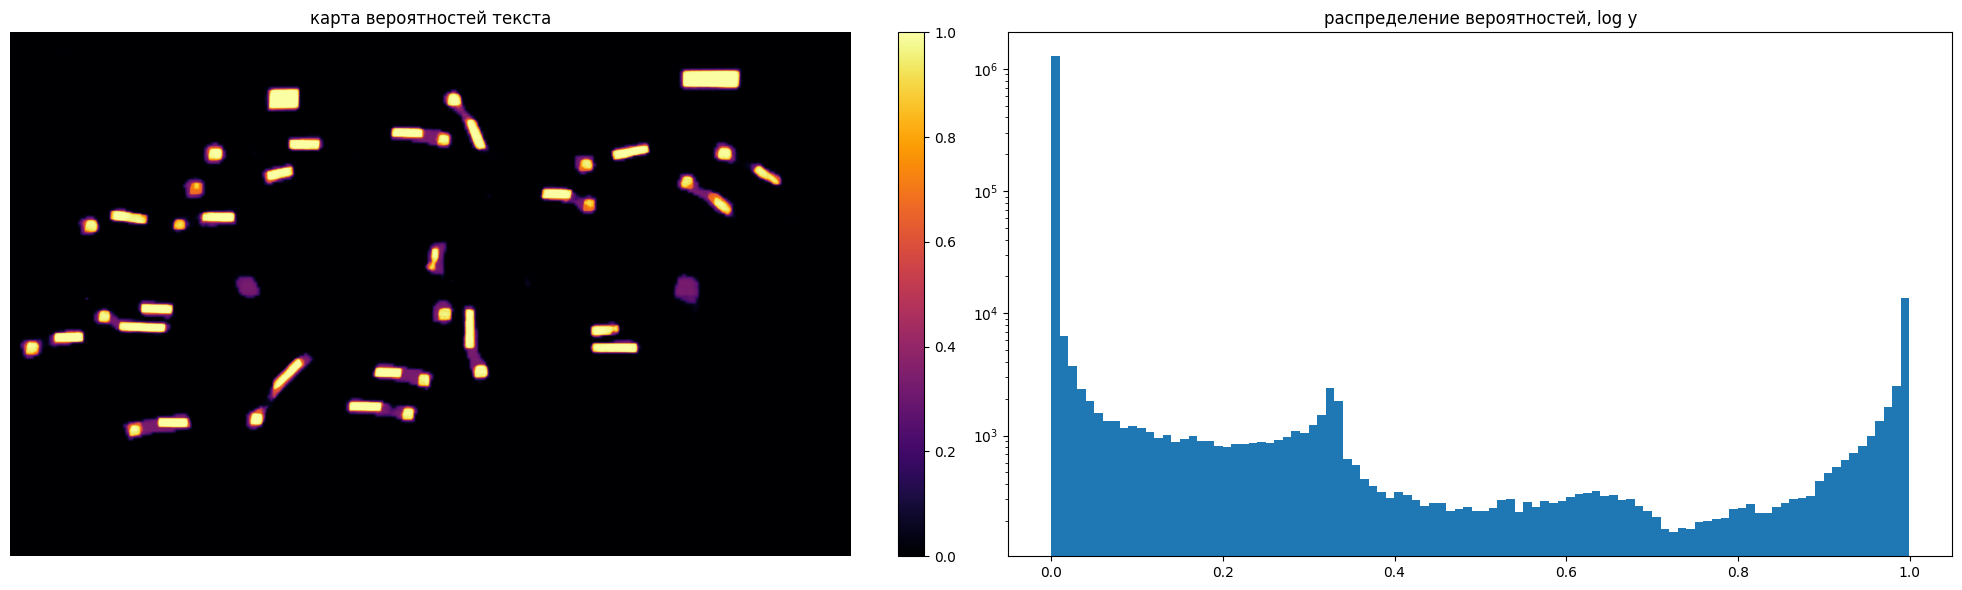

In [11]:
text_prob: Floats = prob_stack.mean(axis=0)
print(f"prob {text_prob.shape} | min {text_prob.min():.3f} max {text_prob.max():.3f}")

fig, (a1, a2) = plt.subplots(1, 2, figsize=(20, 6))
im = a1.imshow(text_prob, cmap="inferno", vmin=0, vmax=1)
a1.set_title("карта вероятностей текста")
a1.axis("off")
fig.colorbar(im, ax=a1, fraction=0.03)
a2.hist(text_prob.ravel(), bins=100, log=True)
a2.set_title("распределение вероятностей, log y")
plt.tight_layout()
plt.show()

Кандидаты по логике DBPostProcess: контуры бинарной карты, minAreaRect, средняя вероятность внутри
прямоугольника. Порог `thresh` отвечает только за связность, решение принимает `box_thresh` по этой
средней. Площадь кандидата тут не участвует вообще.

In [12]:
@dataclass(frozen=True, eq=False)
class Candidates:
    """Кандидаты в текстовые ядра и их метрики."""

    contour: list[Ints]
    score: Floats
    short_side: Floats
    area: Floats
    perimeter: Floats

    def __len__(self) -> int:
        return len(self.contour)


@dataclass(frozen=True, eq=False)
class Kernels:
    """Принятые ядра: только то, что нужно для построения маски."""

    contour: list[Ints]
    area: Floats
    perimeter: Floats

    def __len__(self) -> int:
        return len(self.contour)


def box_score(prob: Floats, box: Floats) -> float:
    """Средняя вероятность внутри четырехугольника, score из DBPostProcess."""
    h, w = prob.shape[:2]
    b = box.copy()
    xmin, xmax = np.clip([np.floor(b[:, 0].min()), np.ceil(b[:, 0].max())], 0, w - 1).astype(np.int32)
    ymin, ymax = np.clip([np.floor(b[:, 1].min()), np.ceil(b[:, 1].max())], 0, h - 1).astype(np.int32)
    m = np.zeros((ymax - ymin + 1, xmax - xmin + 1), dtype=np.uint8)
    b[:, 0] -= xmin
    b[:, 1] -= ymin
    cv2.fillPoly(m, b.reshape(1, -1, 2).astype(np.int32), 1)
    return float(cv2.mean(prob[ymin : ymax + 1, xmin : xmax + 1], m)[0])


def find_candidates(prob: Floats, thresh: float, max_count: int = 1000) -> Candidates:
    """Контуры бинарной карты и их метрики. Решение о приеме принимается отдельно."""
    found, _ = cv2.findContours((prob > thresh).astype(np.uint8), cv2.RETR_LIST, cv2.CHAIN_APPROX_SIMPLE)
    contours = list(found[:max_count])
    rects = [cv2.minAreaRect(c) for c in contours]
    sides = np.array([r[1] for r in rects], dtype=np.float64).reshape(-1, 2)
    return Candidates(
        contour=contours,
        score=np.array([box_score(prob, cv2.boxPoints(r)) for r in rects], dtype=np.float64),
        short_side=sides.min(axis=1) if len(sides) else np.zeros(0),
        area=np.array([cv2.contourArea(c) for c in contours], dtype=np.float64),
        perimeter=np.array([cv2.arcLength(c, True) for c in contours], dtype=np.float64),
    )


def accept_mask(cands: Candidates, box_thresh: float, min_size: float) -> Mask:
    """Прием кандидата: средняя вероятность и минимальная сторона."""
    return (cands.score >= box_thresh) & (cands.short_side >= min_size)


def take_kernels(cands: Candidates, accepted: Mask) -> Kernels:
    """Отбор принятых кандидатов."""
    idx = np.flatnonzero(accepted)
    return Kernels(
        contour=[cands.contour[i] for i in idx],
        area=cands.area[idx],
        perimeter=cands.perimeter[idx],
    )

In [13]:
def report_candidates(cands: Candidates, accepted: Mask) -> None:
    """Отчет по отбору. DataFrame нужен только для печати."""
    print(f"кандидатов {len(cands)} | принято {int(accepted.sum())}")
    if not len(cands):
        return
    table = pd.DataFrame({"score": cands.score, "sside": cands.short_side, "area": cands.area, "keep": accepted})
    print(table.groupby("keep")[["score", "sside", "area"]].median().round(2).to_string())


def draw_candidates(image: Img, cands: Candidates, accepted: Mask, title: str) -> None:
    """Принятые зеленым, отклоненные красным."""
    canvas = image.copy()
    for contour, ok in zip(cands.contour, accepted, strict=True):
        cv2.drawContours(canvas, [contour], -1, (0, 200, 0) if ok else (0, 0, 255), 2)
    show_image(canvas, title, figsize=(18, 10))


def run_candidates(thresh: float, box_thresh: float, min_size: float) -> Kernels:
    """Слайдеры отбора ядер."""
    cands = find_candidates(text_prob, thresh)
    accepted = accept_mask(cands, box_thresh, min_size)
    report_candidates(cands, accepted)
    draw_candidates(img_bgr, cands, accepted, f"ядра: thresh {thresh:.2f} | box_thresh {box_thresh:.2f}")
    return take_kernels(cands, accepted)


ui_cand = interactive(
    run_candidates,
    thresh=FloatSlider(
        value=0.30,
        min=0.05,
        max=0.90,
        step=0.05,
        continuous_update=False,
        description="thresh",
    ),
    box_thresh=FloatSlider(
        value=0.40,
        min=0.10,
        max=0.95,
        step=0.05,
        continuous_update=False,
        description="box_thresh",
    ),
    min_size=FloatSlider(
        value=3.0,
        min=0.0,
        max=20.0,
        step=1.0,
        continuous_update=False,
        description="min сторона",
    ),
)
ui_cand

interactive(children=(FloatSlider(value=0.3, continuous_update=False, description='thresh', max=0.9, min=0.05,…

Маска текстовой области: контур каждого принятого ядра раздувается на `d = area * ratio / perimeter`.
Раздуваем сам контур, а не описанный прямоугольник, форма идет вдоль наклонных надписей и захватывает
меньше лишнего. Бери с запасом: лишний захват линии стоит дешево, пропущенный текст дорого.

In [14]:
def unclip_distance(area: float, perimeter: float, ratio: float) -> int:
    """На сколько пикселей раздуть контур ядра."""
    return int(round(area * ratio / perimeter)) if perimeter > 0 else 0


def dilate_contour(contour: Ints, distance: int, shape: tuple[int, int]) -> Mask:
    """Заливка контура, раздутая на distance. Работает в bbox, а не по всему кадру."""
    h, w = shape
    x, y, bw, bh = cv2.boundingRect(contour)
    pad = distance + 2
    x0, y0 = max(0, x - pad), max(0, y - pad)
    x1, y1 = min(w, x + bw + pad), min(h, y + bh + pad)

    sub = np.zeros((y1 - y0, x1 - x0), np.uint8)
    cv2.drawContours(sub, [contour - np.array([[x0, y0]])], -1, 255, cv2.FILLED)
    if distance > 0:
        far = cv2.distanceTransform(np.where(sub > 0, 0, 255).astype(np.uint8), cv2.DIST_L2, cv2.DIST_MASK_PRECISE)
        sub = np.where((far <= distance) | (sub > 0), 255, 0).astype(np.uint8)

    out = np.zeros(shape, dtype=bool)
    out[y0:y1, x0:x1] = sub > 0
    return out


def build_text_region(kernels: Kernels, ratio: float, shape: tuple[int, int]) -> Mask:
    """Объединение раздутых ядер."""
    region = np.zeros(shape, dtype=bool)
    for contour, area, perimeter in zip(kernels.contour, kernels.area, kernels.perimeter, strict=True):
        region |= dilate_contour(contour, unclip_distance(area, perimeter, ratio), shape)
    return region

In [15]:
def report_region(kernels: Kernels, region: Mask) -> None:
    """Во что развернулись ядра."""
    print(f"ядер {len(kernels)} | область {region.mean() * 100:.3f}% пикселей кадра")


def draw_region(image: Img, region: Mask, title: str) -> None:
    """Полупрозрачная заливка текстовой области."""
    overlay = image.copy()
    overlay[region] = (0, 0, 255)
    show_image(cv2.addWeighted(overlay, 0.45, image, 0.55, 0), title, figsize=(18, 10))


def run_region(unclip_ratio: float) -> Mask:
    """Слайдер раздувания ядер."""
    kernels = ui_cand.result
    region = build_text_region(kernels, unclip_ratio, img_bgr.shape[:2])
    report_region(kernels, region)
    draw_region(img_bgr, region, f"текстовая область: unclip {unclip_ratio:.1f}")
    return region


ui_region = interactive(
    run_region,
    unclip_ratio=FloatSlider(value=1.5, min=0.5, max=4.0, step=0.1, continuous_update=False, description="unclip"),
)
ui_region

interactive(children=(FloatSlider(value=1.5, continuous_update=False, description='unclip', max=4.0, min=0.5),…

## 3. Бинаризация

Штрих темный на светлом, отсюда THRESH_BINARY_INV. Билатеральный фильтр гасит зерно jpeg: без него
тонкие линии рвутся, а разрыв плодит ложные концы в графе. Otsu ставит порог по гистограмме сам.

In [52]:
@dataclass(frozen=True, eq=False)
class Strokes:
    """Штрихи чертежа после бинаризации."""

    gray: Img
    binary: Img
    fg: Mask


def binarize(image: Img) -> Strokes:
    """Otsu по размытой серой картинке."""
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    blurred = cv2.bilateralFilter(gray, d=5, sigmaColor=15, sigmaSpace=15)
    thr, binary = cv2.threshold(blurred, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
    print(f"порог Otsu {thr:.0f} | штрихи занимают {(binary > 0).mean():.1%} кадра")
    return Strokes(gray=gray, binary=binary, fg=binary > 0)

порог Otsu 163 | штрихи занимают 2.8% кадра
кадр 2950x1838 | текстовая область 8.97%


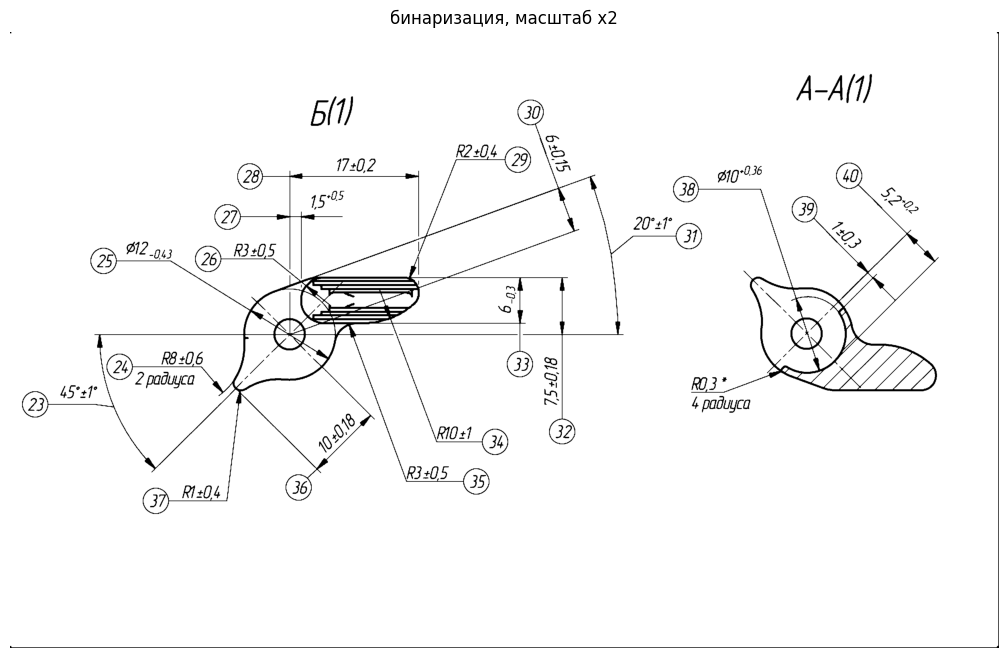

In [53]:
resized: Img = upscale_image(img_bgr, SCALE)
text_region: Mask = upscale_mask(ui_region.result, SCALE)
strokes: Strokes = binarize(resized)

print(f"кадр {resized.shape[1]}x{resized.shape[0]} | текстовая область {text_region.mean() * 100:.2f}%")
show_mask(strokes.fg, f"бинаризация, масштаб x{SCALE:.0f}")

## 4. Граф скелета и толщина штриха

distanceTransform дает расстояние до фона, то есть половину локальной ширины. Значения снимаем
только с медиальной оси: на краях штриха оценка занижена по построению и смазывает гистограмму.
Доля текста считается сразу по пикселям ребра, промежуточного порога на ребре нет.

In [18]:
def group_median(values: Floats, groups: Ints, count: int) -> Floats:
    """Медиана по группам без pandas. Пустая группа -> nan."""
    order = np.lexsort((values, groups))
    sorted_values, sorted_groups = values[order], groups[order]
    starts = np.searchsorted(sorted_groups, np.arange(count), side="left")
    stops = np.searchsorted(sorted_groups, np.arange(count), side="right")
    out = np.full(count, np.nan)
    filled = stops > starts
    out[filled] = sorted_values[((starts + stops) // 2)[filled]]
    return out


def path_thickness(skeleton: Skeleton, dist: Floats, trim: float = 0.25) -> Floats:
    """Толщина ребра = медиана 2r-1 по срединной части: узлы и концы отброшены."""
    n_px = np.diff(skeleton.paths.indptr)
    pid = np.repeat(np.arange(skeleton.n_paths), n_px)
    pos = np.arange(len(pid)) - np.repeat(skeleton.paths.indptr[:-1], n_px)
    inner = (pos >= trim * np.repeat(n_px, n_px)) & (pos < (1 - trim) * np.repeat(n_px, n_px))

    rc = skeleton.coordinates[skeleton.paths.indices].astype(int)
    values = 2 * dist[rc[:, 0], rc[:, 1]] - 1
    return group_median(values[inner], pid[inner], skeleton.n_paths)


def path_id_image(skeleton: Skeleton, shape: tuple[int, int]) -> Ints:
    """Карта пикселей скелета -> id пути, -1 вне скелета."""
    img = np.full(shape, -1, dtype=np.int64)
    rc = skeleton.coordinates[skeleton.paths.indices].astype(int)
    img[rc[:, 0], rc[:, 1]] = np.repeat(np.arange(skeleton.n_paths), np.diff(skeleton.paths.indptr))
    return img


def owner_image(pid: Ints, fg: Mask) -> Ints:
    """Каждый пиксель штриха относим к ближайшему пути скелета, -1 вне штрихов."""
    _, lbl = cv2.distanceTransformWithLabels(
        (pid < 0).astype(np.uint8), cv2.DIST_L2, cv2.DIST_MASK_PRECISE, labelType=cv2.DIST_LABEL_PIXEL
    )
    on_skel = pid >= 0
    lut = np.full(int(lbl.max()) + 1, -1, dtype=np.int64)
    lut[lbl[on_skel]] = pid[on_skel]
    return np.where(fg, lut[lbl], -1)


def path_text_share(skeleton: Skeleton, text_region: Mask) -> Floats:
    """Доля пикселей ребра внутри маски текста. -> (n_paths,)"""
    rc = skeleton.coordinates[skeleton.paths.indices].astype(int)
    pid = np.repeat(np.arange(skeleton.n_paths), np.diff(skeleton.paths.indptr))
    inside = text_region[rc[:, 0], rc[:, 1]].astype(np.float64)
    return np.bincount(pid, weights=inside, minlength=skeleton.n_paths) / np.maximum(np.diff(skeleton.paths.indptr), 1)

In [19]:
@dataclass(frozen=True, eq=False)
class StrokeGraph:
    """Скелет чертежа: ребра, их геометрия и связи."""

    skeleton: Skeleton
    dist: Floats  # distance transform, половина ширины штриха
    pid: Ints  # пиксель скелета -> id пути
    owner: Ints  # пиксель штриха -> id пути
    thickness: Floats  # по ребрам
    length: Floats
    pixels: Ints  # число пикселей оси ребра
    branch: Ints  # тип ребра: 0 изолят, 1 шпора, 2 узел-узел, 3 цикл
    src: Ints
    dst: Ints
    degree: Ints  # степень узла
    text_share: Floats  # доля пикселей ребра в маске текста

    @property
    def n_paths(self) -> int:
        return int(self.skeleton.n_paths)

    @property
    def is_text(self) -> Mask:
        return self.text_share > TEXT_LIMIT

    @property
    def median_thickness(self) -> float:
        return float(np.nanmedian(self.thickness))

    def xy(self, path: int) -> Floats:
        """Точки ребра в порядке (x, y) для matplotlib."""
        return self.skeleton.path_coordinates(path)[:, ::-1]


def build_graph(strokes: Strokes, text_region: Mask) -> StrokeGraph:
    """Скелетизация, толщина каждого ребра и его доля текста."""
    skel = skeletonize(strokes.fg)
    dist = cv2.distanceTransform(strokes.binary, cv2.DIST_L2, cv2.DIST_MASK_PRECISE).astype(np.float64)
    skeleton = Skeleton(skel)
    summary = summarize(skeleton, separator="-")
    pid = path_id_image(skeleton, skel.shape)
    src = summary["node-id-src"].to_numpy()
    dst = summary["node-id-dst"].to_numpy()

    print(f"путей {skeleton.n_paths} | пикселей оси {int(np.diff(skeleton.paths.indptr).sum())}")
    return StrokeGraph(
        skeleton=skeleton,
        dist=dist,
        pid=pid,
        owner=owner_image(pid, strokes.fg),
        thickness=path_thickness(skeleton, dist),
        length=summary["branch-distance"].to_numpy(),
        pixels=np.diff(skeleton.paths.indptr),
        branch=summary["branch-type"].to_numpy(),
        src=src,
        dst=dst,
        degree=np.bincount(np.concatenate([src, dst]), minlength=len(skeleton.coordinates)),
        text_share=path_text_share(skeleton, text_region),
    )

In [54]:
BRANCH_NAMES: dict[int, str] = {0: "конец-конец (изолят)", 1: "узел-конец (шпора)", 2: "узел-узел", 3: "цикл"}


def report_graph(graph: StrokeGraph) -> None:
    """Состав скелета по типам ребер. DataFrame нужен только для печати."""
    short = graph.length < 2 * graph.median_thickness
    table = pd.DataFrame({"branch": graph.branch, "len": graph.length, "short": short, "text": graph.is_text})
    grouped = table.groupby("branch")
    report = pd.DataFrame(
        {
            "n": grouped.size(),
            "len_sum": grouped["len"].sum().round(0),
            "len_share": (grouped["len"].sum() / graph.length.sum()).round(3),
            "n_short": grouped["short"].sum(),
            "n_text": grouped["text"].sum(),
        }
    )
    report.index = [BRANCH_NAMES.get(int(i), str(i)) for i in report.index]

    print(f"ребер {graph.n_paths} | медиана толщины {graph.median_thickness:.1f} px")
    print(report.to_string())
    degrees = graph.degree[graph.degree > 0]
    print(
        f"узлов {len(degrees)} | концов {int((degrees == 1).sum())}"
        f" | deg=2 {int((degrees == 2).sum())} | стыков {int((degrees >= 3).sum())}"
    )
    print(f"текстовых ребер {int(graph.is_text.sum())} ({graph.is_text.mean():.1%})")

In [55]:
graph: StrokeGraph = build_graph(strokes, text_region)
segments: list[Floats] = [graph.xy(i) for i in range(graph.n_paths)]
bounds: Floats = np.array([[s[:, 0].min(), s[:, 0].max(), s[:, 1].min(), s[:, 1].max()] for s in segments])

report_graph(graph)

путей 980 | пикселей оси 42224
ребер 980 | медиана толщины 3.0 px
                        n  len_sum  len_share  n_short  n_text
конец-конец (изолят)   69   7238.0      0.157       10      52
узел-конец (шпора)    398   7102.0      0.154      123     309
узел-узел             455  24533.0      0.531      111     109
цикл                   58   7305.0      0.158        0      57
узлов 1016 | концов 536 | deg=2 26 | стыков 454
текстовых ребер 527 (53.8%)


Просмотрщик графа. Окно задается центром и зумом, подписи включаются флажком и печатаются только
если ребер в кадре немного.

In [22]:
def view_window(cx: float, cy: float, zoom: float) -> Window:
    """Окно просмотра -> (x0, x1, y0, y1) в пикселях."""
    h, w = resized.shape[:2]
    half = max(h, w) / (2 * zoom)
    return cx * w - half, cx * w + half, cy * h - half, cy * h + half


def paths_in_window(win: Window) -> Mask:
    """Ребра, задевшие окно. -> (n_paths,)"""
    x0, x1, y0, y1 = win
    return (bounds[:, 0] <= x1) & (bounds[:, 1] >= x0) & (bounds[:, 2] <= y1) & (bounds[:, 3] >= y0)


def nodes_in_window(win: Window) -> Ints:
    """Индексы узлов внутри окна."""
    x0, x1, y0, y1 = win
    y, x = graph.skeleton.coordinates[:, 0], graph.skeleton.coordinates[:, 1]
    return np.flatnonzero((graph.degree > 0) & (x >= x0) & (x <= x1) & (y >= y0) & (y <= y1))


def ax_view(win: Window, title: str, figsize: tuple[float, float] = (18, 11)) -> Axes:
    """Оси с подложкой и выставленным окном."""
    x0, x1, y0, y1 = win
    _, ax = plt.subplots(figsize=figsize)
    ax.imshow(cv2.cvtColor(resized, cv2.COLOR_BGR2GRAY), cmap="gray", alpha=0.4)
    ax.set_xlim(x0, x1)
    ax.set_ylim(y1, y0)
    ax.axis("off")
    ax.set_title(title)
    return ax


def view_sliders() -> dict[str, FloatSlider]:
    """Одинаковый набор слайдеров окна для любого визуализатора."""
    return dict(
        cx=FloatSlider(value=0.5, min=0.0, max=1.0, step=0.02, continuous_update=False, description="центр X"),
        cy=FloatSlider(value=0.5, min=0.0, max=1.0, step=0.02, continuous_update=False, description="центр Y"),
        zoom=FloatSlider(value=1.0, min=1.0, max=12.0, step=0.5, continuous_update=False, description="зум"),
    )


def draw_paths(ax: Axes, paths: Ints, colors, width: float = 1.8, dashed: Mask | None = None, zorder: int = 2) -> None:
    """Отрисовка ребер скелета одним LineCollection."""
    styles = np.where(dashed, "dashed", "solid").tolist() if dashed is not None else "solid"
    ax.add_collection(
        LineCollection([segments[i] for i in paths], colors=colors, linewidths=width, linestyles=styles, zorder=zorder)
    )

In [23]:
NODE_KINDS: tuple[tuple[int, int, str, str, str], ...] = (
    (1, 1, "red", "o", "конец"),
    (2, 2, "yellow", "^", "deg=2"),
    (3, 99, "cyan", "s", "стык"),
)


def draw_nodes(ax: Axes, nodes: Ints) -> None:
    """Узлы по степени: свободный конец, deg=2, стык."""
    for lo, hi, color, marker, name in NODE_KINDS:
        sel = nodes[(graph.degree[nodes] >= lo) & (graph.degree[nodes] <= hi)]
        ax.scatter(
            graph.skeleton.coordinates[sel, 1],
            graph.skeleton.coordinates[sel, 0],
            s=26,
            c=color,
            marker=marker,
            edgecolors="k",
            linewidths=0.4,
            zorder=3,
            label=f"{name} {len(sel)}",
        )


def draw_path_labels(ax: Axes, paths: Ints, limit: int = 80) -> None:
    """Подписи id, длины и толщины у видимых ребер."""
    if len(paths) > limit:
        print(f"подписи скрыты: ребер {len(paths)} > {limit}, добавь зум или min_len")
        return
    for i in paths:
        x, y = segments[i][len(segments[i]) // 2]
        ax.text(x, y, f"{i}\n{graph.length[i]:.0f}/{graph.thickness[i]:.1f}", fontsize=7, ha="center", va="center")


def report_window(paths: Ints, nodes: Ints) -> None:
    """Состав кадра."""
    if len(paths):
        print(
            f"ребер в кадре {len(paths)} | длины: медиана {np.median(graph.length[paths]):.0f}, max {graph.length[paths].max():.0f}"
        )
    else:
        print("ребер в кадре нет")
    print(f"узлов {len(nodes)} | текстовых ребер {int(graph.is_text[paths].sum())}")


def run_graph(cx: float, cy: float, zoom: float, min_len: int, labels: bool) -> None:
    """Ребра случайными цветами, узлы по степени, пунктир у текстовых."""
    win = view_window(cx, cy, zoom)
    paths = np.flatnonzero(paths_in_window(win) & (graph.length >= min_len))
    nodes = nodes_in_window(win)
    report_window(paths, nodes)

    ax = ax_view(win, f"граф скелета | зум {zoom:.1f}x | пунктир это текст | подпись: id / длина / толщина")
    draw_paths(ax, paths, path_colors[paths], dashed=graph.is_text[paths])
    draw_nodes(ax, nodes)
    if labels:
        draw_path_labels(ax, paths)
    ax.legend(loc="upper right", fontsize=8)
    plt.show()


path_colors: Floats = plt.cm.hsv(np.random.default_rng(0).random(graph.n_paths))
ui_graph = interactive(
    run_graph,
    **view_sliders(),
    min_len=IntSlider(value=0, min=0, max=60, step=1, continuous_update=False, description="min len, px"),
    labels=Checkbox(value=False, description="подписи"),
)
ui_graph

interactive(children=(FloatSlider(value=0.5, continuous_update=False, description='центр X', max=1.0, step=0.0…

## 5. Склейка ребер в цепи

Скелет рвет линию на ребра в каждом пересечении. Цепь собирает их обратно: два конца в одном
супер-узле склеиваются, если продолжают друг друга по направлению, лежат на одной прямой и близки
по толщине. Самокольца остаются в выборке, иначе теряются буквы 0 и О и кружки позиций.

In [24]:
@dataclass(frozen=True)
class Gates:
    """Ворота склейки пары концов."""

    max_dev: float = 20.0  # отклонение от прямой, градусы
    max_off: float = 7.5  # поперечный сдвиг, px
    t_ratio: float = 1.6  # допустимое отношение толщин


@dataclass(frozen=True)
class MergeParams:
    """Параметры шага склейки."""

    r_node: float = 8.0  # радиус схлопывания стыков в супер-узел
    tan_len: int = 12  # длина участка для оценки касательной
    gates: Gates = Gates()


@dataclass(frozen=True, eq=False)
class SuperNodes:
    """Стыки, соединенные коротким ребром, схлопнуты в один узел."""

    label: Ints  # узел -> метка супер-узла
    absorbed: Mask  # ребра, поглощенные супер-узлом


def build_super_nodes(graph: StrokeGraph, r_node: float) -> SuperNodes:
    """Схлопывание близких стыков."""
    absorbed = (graph.length < r_node) & (graph.degree[graph.src] >= 3) & (graph.degree[graph.dst] >= 3)
    n = len(graph.skeleton.coordinates)
    g = coo_matrix((np.ones(absorbed.sum()), (graph.src[absorbed], graph.dst[absorbed])), shape=(n, n))
    return SuperNodes(label=connected_components(g, directed=False)[1], absorbed=absorbed)


def end_tangents(graph: StrokeGraph, tan_len: int) -> Floats:
    """Направление в каждом конце ребра, от узла внутрь. -> (n_paths, 2, 2) в (dy, dx)"""
    out = np.zeros((graph.n_paths, 2, 2))
    for i in range(graph.n_paths):
        coords = graph.skeleton.path_coordinates(i).astype(float)
        k = max(2, min(int(tan_len), len(coords)))
        for side in (0, 1):
            pts = coords[:k] if side == 0 else coords[::-1][:k]
            u = np.linalg.svd(pts - pts.mean(0), full_matrices=False)[2][0]
            out[i, side] = u if u @ (pts[-1] - pts[0]) > 0 else -u
    return out

In [25]:
@dataclass(frozen=True, eq=False)
class Ends:
    """Концы ребер, участвующих в склейке. Все массивы одной длины."""

    path: Ints
    node: Ints  # метка супер-узла
    degree: Ints
    point: Floats  # (n, 2) в (y, x)
    direction: Floats  # (n, 2) наружу из ребра
    thickness: Floats

    def __len__(self) -> int:
        return len(self.path)


def build_ends(graph: StrokeGraph, paths: Ints, nodes: SuperNodes, tangents: Floats) -> Ends:
    """Таблица концов: по два конца на каждое ребро из paths."""
    path = np.repeat(paths, 2)
    side = np.tile(np.array([0, 1]), len(paths))
    raw_node = np.where(side == 0, graph.src[path], graph.dst[path])
    point = np.array(
        [graph.skeleton.path_coordinates(p)[0 if s == 0 else -1] for p, s in zip(path, side, strict=True)], dtype=float
    )
    return Ends(
        path=path,
        node=nodes.label[raw_node],
        degree=graph.degree[raw_node],
        point=point,
        direction=tangents[path, side],
        thickness=graph.thickness[path],
    )


def perp_offset(pa: Floats, da: Floats, pb: Floats, db: Floats) -> float:
    """Насколько конец b не лежит на прямой конца a, и наоборот."""
    v = pb - pa
    return float(max(abs(v[0] * da[1] - v[1] * da[0]), abs(v[0] * db[1] - v[1] * db[0])))


def thickness_ok(ta: float, tb: float, ratio: float) -> bool:
    """Толщины сопоставимы, nan пропускаем."""
    if not (np.isfinite(ta) and np.isfinite(tb)):
        return True
    return max(ta, tb) <= ratio * max(min(ta, tb), 1e-6)


def pair_deviation(ends: Ends, a: int, b: int, gates: Gates, off_scale: float = 1.0) -> float | None:
    """Отклонение пары от прямой в градусах или None, если ворота не пройдены."""
    dev = float(np.degrees(np.arccos(np.clip(-float(ends.direction[a] @ ends.direction[b]), -1.0, 1.0))))
    off = perp_offset(ends.point[a], ends.direction[a], ends.point[b], ends.direction[b])
    if dev > gates.max_dev or off > off_scale * gates.max_off:
        return None
    if not thickness_ok(ends.thickness[a], ends.thickness[b], gates.t_ratio):
        return None
    return dev


def group_by_node(ends: Ends) -> list[Ints]:
    """Индексы концов, сгруппированные по супер-узлу."""
    order = np.argsort(ends.node, kind="stable")
    return np.split(order, np.flatnonzero(np.diff(ends.node[order])) + 1)


def candidate_pairs(ends: Ends, gates: Gates) -> list[tuple[int, int]]:
    """Пары концов внутри супер-узла, прошедшие ворота. Самые прямые первыми."""
    scored: list[tuple[float, int, int]] = []
    for group in group_by_node(ends):
        for a, b in combinations(group.tolist(), 2):
            if ends.path[a] == ends.path[b]:
                continue
            dev = pair_deviation(ends, a, b, gates)
            if dev is not None:
                scored.append((dev, a, b))
    scored.sort()
    return [(a, b) for _, a, b in scored]


def greedy_match(pairs: list[tuple[int, int]], n_ends: int) -> list[tuple[int, int]]:
    """Жадное паросочетание: каждый конец участвует один раз."""
    taken = np.zeros(n_ends, dtype=bool)
    matched: list[tuple[int, int]] = []
    for a, b in pairs:
        if not (taken[a] or taken[b]):
            taken[a] = taken[b] = True
            matched.append((a, b))
    return matched

In [26]:
@dataclass(frozen=True, eq=False)
class Chains:
    """Цепи: ребра, собранные обратно в линии."""

    n_paths: int  # размер скелета, чтобы разворачивать решения по цепям в маску путей
    paths: Ints  # id ребер, попавших в цепи
    label: Ints  # метка цепи для каждого элемента paths
    length: Floats  # по цепям
    thickness: Floats
    text_share: Floats

    @property
    def count(self) -> int:
        return len(self.length)

    @property
    def is_text(self) -> Mask:
        return self.text_share > TEXT_LIMIT

    def path_mask(self, keep: Mask) -> Mask:
        """Решение по цепям -> маска ребер скелета. -> (n_paths,)"""
        mask = np.zeros(self.n_paths, dtype=bool)
        mask[self.paths] = keep[self.label]
        return mask


def weighted_median(values: Floats, weights: Floats) -> float:
    """Медиана, взвешенная длиной звена."""
    finite = np.isfinite(values)
    values, weights = values[finite], weights[finite]
    if not len(values):
        return float("nan")
    order = np.argsort(values)
    cumulative = np.cumsum(weights[order])
    return float(values[order][np.searchsorted(cumulative, 0.5 * cumulative[-1])])


def chain_labels(pairs: list[tuple[int, int]], ends: Ends, paths: Ints, n_paths: int) -> Ints:
    """Склеенные ребра -> метка цепи для каждого элемента paths."""
    pos = np.full(n_paths, -1)
    pos[paths] = np.arange(len(paths))
    rows = [pos[ends.path[a]] for a, b in pairs]
    cols = [pos[ends.path[b]] for a, b in pairs]
    g = coo_matrix((np.ones(len(rows)), (rows, cols)), shape=(len(paths), len(paths)))
    return connected_components(g, directed=False)[1]


def chain_thickness(label: Ints, thickness: Floats, length: Floats, count: int) -> Floats:
    """Толщина цепи = медиана толщин звеньев, взвешенная их длиной."""
    out = np.full(count, np.nan)
    for c in range(count):
        members = label == c
        out[c] = weighted_median(thickness[members], length[members])
    return out


def chain_text_share(label: Ints, text_share: Floats, pixels: Ints, count: int) -> Floats:
    """Доля пикселей цепи в маске текста. Порог применяется один раз, уже к цепи."""
    inside = np.bincount(label, weights=text_share * pixels, minlength=count)
    total = np.bincount(label, weights=pixels.astype(np.float64), minlength=count)
    return inside / np.maximum(total, 1.0)


def build_chains(graph: StrokeGraph, params: MergeParams) -> Chains:
    """Склейка ребер в цепи по прямизне, сдвигу и толщине."""
    nodes = build_super_nodes(graph, params.r_node)
    paths = np.flatnonzero(~nodes.absorbed)  # самокольца остаются, поглощенные стыком нет
    ends = build_ends(graph, paths, nodes, end_tangents(graph, params.tan_len))
    matched = greedy_match(candidate_pairs(ends, params.gates), len(ends))
    label = chain_labels(matched, ends, paths, graph.n_paths)
    count = int(label.max()) + 1

    print(f"ребер {graph.n_paths} | в склейке {len(paths)} | склеено пар {len(matched)} -> цепей {count}")
    return Chains(
        n_paths=graph.n_paths,
        paths=paths,
        label=label,
        length=np.bincount(label, weights=graph.length[paths], minlength=count),
        thickness=chain_thickness(label, graph.thickness[paths], graph.length[paths], count),
        text_share=chain_text_share(label, graph.text_share[paths], graph.pixels[paths], count),
    )

In [27]:
def report_chains(graph: StrokeGraph, chains: Chains) -> None:
    """Во что схлопнулся граф."""
    table = pd.DataFrame({"len": chains.length, "t": chains.thickness, "text": chains.text_share})
    print(
        f"цепей {chains.count} | текстовых {int(chains.is_text.sum())} | звеньев на цепь {len(chains.paths) / chains.count:.2f}"
    )
    print(
        f"длина: было медиана {np.median(graph.length[chains.paths]):.0f} -> стало {np.median(chains.length):.0f}, max {chains.length.max():.0f}"
    )
    print("\n5 самых длинных цепей:")
    print(table.sort_values("len", ascending=False).head(5).round(2).to_string())


def draw_chains(win: Window, chains: Chains, title: str) -> None:
    """Один цвет это одна цепь."""
    ax = ax_view(win, title)
    visible = paths_in_window(win)[chains.paths]
    colors = plt.cm.hsv(np.random.default_rng(1).permutation(chains.count) / max(chains.count - 1, 1))
    draw_paths(ax, chains.paths[visible], colors[chains.label[visible]], width=2.0)
    plt.show()


def run_merge(
    cx: float, cy: float, zoom: float, r_node: float, tan_len: int, max_dev: float, max_off: float, t_ratio: float
) -> Chains:
    """Слайдеры склейки."""
    params = MergeParams(r_node=r_node, tan_len=tan_len, gates=Gates(max_dev, max_off, t_ratio))
    chains = build_chains(graph, params)
    report_chains(graph, chains)
    draw_chains(
        view_window(cx, cy, zoom),
        chains,
        f"цепи | r={r_node} tan={tan_len} | dev<{max_dev} град, off<{max_off} px, t<{t_ratio}x",
    )
    return chains


ui_merge = interactive(
    run_merge,
    **view_sliders(),
    r_node=FloatSlider(value=8.0, min=0.0, max=20.0, step=0.5, continuous_update=False, description="r узла, px"),
    tan_len=IntSlider(value=12, min=3, max=40, step=1, continuous_update=False, description="касат., px"),
    max_dev=FloatSlider(value=20.0, min=0.0, max=45.0, step=1.0, continuous_update=False, description="угол, град"),
    max_off=FloatSlider(value=7.5, min=0.0, max=20.0, step=0.5, continuous_update=False, description="сдвиг, px"),
    t_ratio=FloatSlider(value=1.6, min=1.0, max=3.0, step=0.1, continuous_update=False, description="t max/min"),
)
ui_merge

interactive(children=(FloatSlider(value=0.5, continuous_update=False, description='центр X', max=1.0, step=0.0…

In [28]:
chains: Chains = ui_merge.result
print(f"цепей {chains.count} | звеньев {len(chains.paths)} | текстовых цепей {int(chains.is_text.sum())}")

цепей 607 | звеньев 853 | текстовых цепей 397


Диагностика разрывов: встречные свободные концы нетекстовых ребер, которые не попали в одну цепь.
Граф они не меняют, это только счет незакрытых стыков.

In [29]:
def find_gaps(graph: StrokeGraph, params: MergeParams, gap_r: float) -> Floats:
    """Пары точек незакрытых разрывов. -> (n, 2, 2) в (y, x)"""
    nodes = build_super_nodes(graph, params.r_node)
    paths = np.flatnonzero(~nodes.absorbed)
    ends = build_ends(graph, paths, nodes, end_tangents(graph, params.tan_len))
    free = np.flatnonzero((ends.degree == 1) & (graph.text_share[ends.path] <= TEXT_LIMIT))
    if len(free) < 2 or gap_r <= 0:
        print("свободных концов нет или радиус нулевой")
        return np.zeros((0, 2, 2))

    found: list[list[Floats]] = []
    for a, b in cKDTree(ends.point[free]).query_pairs(gap_r):
        i, j = int(free[a]), int(free[b])
        towards = -ends.direction[i] @ (ends.point[j] - ends.point[i]) > 0
        if towards and pair_deviation(ends, i, j, params.gates, off_scale=2.0) is not None:
            found.append([ends.point[i], ends.point[j]])
    print(f"свободных концов {len(free)} | встречных пар в радиусе {gap_r:.0f} px: {len(found)}")
    return np.array(found) if found else np.zeros((0, 2, 2))


def draw_gaps(win: Window, gaps: Floats, title: str) -> None:
    """Красный пунктир на месте разрыва."""
    ax = ax_view(win, title)
    draw_paths(ax, chains.paths, "0.6", width=1.0)
    if len(gaps):
        ax.add_collection(
            LineCollection(
                [[p[::-1], q[::-1]] for p, q in gaps], colors="red", linewidths=1.6, linestyles="dashed", zorder=5
            )
        )
    plt.show()


def run_gaps(cx: float, cy: float, zoom: float, gap_r: float) -> Floats:
    """Слайдер радиуса поиска разрывов."""
    gaps = find_gaps(graph, MergeParams(), gap_r)
    draw_gaps(view_window(cx, cy, zoom), gaps, f"разрывы в радиусе {gap_r:.0f} px: {len(gaps)}")
    return gaps


ui_gaps = interactive(
    run_gaps,
    **view_sliders(),
    gap_r=FloatSlider(value=12.0, min=0.0, max=40.0, step=1.0, continuous_update=False, description="радиус, px"),
)
ui_gaps

interactive(children=(FloatSlider(value=0.5, continuous_update=False, description='центр X', max=1.0, step=0.0…

## 6. Классы толщины

Одномерный KMeans по толщине цепей. Текст и цепи с неопределенной толщиной в обучении не участвуют,
иначе буквы стягивают границы классов вниз.

In [30]:
@dataclass(frozen=True, eq=False)
class ThicknessClasses:
    """Классы толщины, пронумерованные по возрастанию."""

    label: Ints  # по цепям, -1 это текст или nan
    centers: Floats
    edges: Floats  # границы между соседними классами


def fit_classes(chains: Chains, k: int, weighted: bool) -> ThicknessClasses:
    """KMeans по толщине цепей. Обучение только на детали."""
    usable = np.isfinite(chains.thickness) & ~chains.is_text
    km = KMeans(n_clusters=k, n_init=10, random_state=0).fit(
        chains.thickness[usable, None], sample_weight=chains.length[usable] if weighted else None
    )
    order = np.argsort(km.cluster_centers_.ravel())
    rank = np.empty(k, dtype=int)
    rank[order] = np.arange(k)
    centers = km.cluster_centers_.ravel()[order]

    label = np.full(chains.count, -1, dtype=np.int64)
    label[usable] = rank[km.labels_]
    print(f"обучено на {int(usable.sum())} цепях из {chains.count}")
    return ThicknessClasses(label=label, centers=centers, edges=(centers[:-1] + centers[1:]) / 2)


def report_classes(chains: Chains, classes: ThicknessClasses) -> None:
    """Центры, границы и наполнение классов."""
    print(f"центры, px:  {np.round(classes.centers, 2)} | в оригинале {np.round(classes.centers / SCALE, 2)}")
    print(f"границы, px: {np.round(classes.edges, 2)} | в оригинале {np.round(classes.edges / SCALE, 2)}")
    total = chains.length[classes.label >= 0].sum()
    for c in range(len(classes.centers)):
        members = classes.label == c
        print(
            f"класс {c}: цепей {int(members.sum())} | длина {chains.length[members].sum() / total:.1%}"
            f" | t от {chains.thickness[members].min():.1f} до {chains.thickness[members].max():.1f}"
        )


def draw_classes(chains: Chains, classes: ThicknessClasses, title: str) -> None:
    """Цвет по классу толщины, текст серым."""
    palette = np.array(PALETTE[: len(classes.centers)], dtype=float) / 255
    colors = np.where(
        (classes.label < 0)[chains.label][:, None],
        np.array([0.55, 0.55, 0.55]),
        palette[classes.label.clip(0)[chains.label]],
    )
    fig, ax = plt.subplots(figsize=(18, 10))
    ax.imshow(resized[..., ::-1])
    draw_paths(ax, chains.paths, colors, width=1.2)
    ax.axis("off")
    ax.set_title(title)
    plt.show()

In [31]:
def run_classes(k: int, weighted: bool) -> ThicknessClasses:
    """Слайдер числа классов."""
    classes = fit_classes(chains, k, weighted)
    report_classes(chains, classes)
    draw_classes(chains, classes, f"{k} классов | границы {np.round(classes.edges, 1)} px")
    return classes


ui_cls = interactive(
    run_classes,
    k=IntSlider(value=2, min=2, max=6, step=1, continuous_update=False, description="классов"),
    weighted=Checkbox(value=True, description="вес по длине"),
)
ui_cls

interactive(children=(IntSlider(value=2, continuous_update=False, description='классов', max=6, min=2), Checkb…

In [32]:
classes: ThicknessClasses = ui_cls.result
print(f"классов {len(classes.centers)} | цепей без класса {int((classes.label < 0).sum())}")

классов 2 | цепей без класса 397


## 7. Перерисовка сохраненных линий

Удалять пиксели нельзя: карта owner делит пиксели между ребрами по близости, и в месте, где тонкая
линия упирается в контур, часть пикселей контура принадлежит тонкому ребру. Поэтому сохраненные
линии рисуются заново от своей оси, каждая осевая точка раздувается на собственный радиус из dist.
Удаленное исчезает не вычитанием, а тем, что его просто не рисуют.

In [33]:
def keep_by_class(chains: Chains, classes: ThicknessClasses, class_min: int) -> Mask:
    """Цепи класса class_min и выше, не текст."""
    return (classes.label >= class_min) & ~chains.is_text


def paint_paths(graph: StrokeGraph, keep_paths: Mask, fg: Mask, tol: float) -> Mask:
    """Заливка сохраненных линий от их оси. Ширина берется в ближайшей осевой точке."""
    kept_skel = (graph.pid >= 0) & keep_paths[np.maximum(graph.pid, 0)]
    if not kept_skel.any():
        return np.zeros_like(fg)

    far, lbl = cv2.distanceTransformWithLabels(
        (~kept_skel).astype(np.uint8), cv2.DIST_L2, cv2.DIST_MASK_PRECISE, labelType=cv2.DIST_LABEL_PIXEL
    )
    radius = np.zeros(int(lbl.max()) + 1, dtype=np.float32)
    radius[lbl[kept_skel]] = graph.dist[kept_skel]
    return fg & (far <= radius[lbl] + tol)


def cut_by_owner(graph: StrokeGraph, keep_paths: Mask, fg: Mask) -> Mask:
    """Что удалил бы наивный подход через owner. Нужно только для контроля."""
    return fg & (graph.owner >= 0) & ~keep_paths[np.maximum(graph.owner, 0)]

In [34]:
def report_clean(chains: Chains, keep: Mask, mask: Mask, fg: Mask, rescued: Mask) -> None:
    """Сколько осталось и сколько спасла перерисовка."""
    components = cv2.connectedComponents(mask.astype(np.uint8) * 255)[0] - 1
    print(f"цепей {int(keep.sum())}/{chains.count} | длины {chains.length[keep].sum() / chains.length.sum():.1%}")
    print(f"чернил {mask.sum() / fg.sum():.1%} | компонент {components}")
    print(f"спасено от выкусывания {int(rescued.sum())} px на стыках")


def draw_clean(image: Img, fg: Mask, mask: Mask, rescued: Mask, title: str) -> None:
    """Слева удаленное красным и спасенное зеленым, справа результат."""
    # overlay = image.copy()
    # overlay[fg & ~mask] = (60, 60, 255)
    # overlay[rescued] = (0, 200, 0)

    # fig, (a1, a2) = plt.subplots(1, 2, figsize=(20, 8))
    # a1.imshow(overlay[..., ::-1])
    # a1.set_title("красное убрано, зеленое спасено перерисовкой")
    # a2.imshow(np.where(mask, 0, 255).astype(np.uint8), cmap="gray")
    # a2.set_title(title)
    # for ax in (a1, a2):
    #     ax.axis("off")

    plt.figure(figsize=(20, 8))
    plt.imshow(np.where(mask, 0, 255).astype(np.uint8), cmap="gray")
    plt.title(title)
    plt.axis("off")
    plt.show()


def run_clean(class_min: int, tol: float) -> Mask:
    """Слайдеры финальной маски."""
    keep = keep_by_class(chains, classes, class_min)
    keep_paths = chains.path_mask(keep)
    mask = paint_paths(graph, keep_paths, strokes.fg, tol)
    rescued = mask & cut_by_owner(graph, keep_paths, strokes.fg)
    report_clean(chains, keep, mask, strokes.fg, rescued)
    draw_clean(resized, strokes.fg, mask, rescued, f"классы >= {class_min}, допуск {tol:.1f} px")
    return mask


ui_clean = interactive(
    run_clean,
    class_min=IntSlider(value=1, min=0, max=5, step=1, continuous_update=False, description="класс >="),
    tol=FloatSlider(value=0.5, min=0.0, max=2.0, step=0.1, continuous_update=False, description="допуск, px"),
)
ui_clean

interactive(children=(IntSlider(value=1, continuous_update=False, description='класс >=', max=5), FloatSlider(…

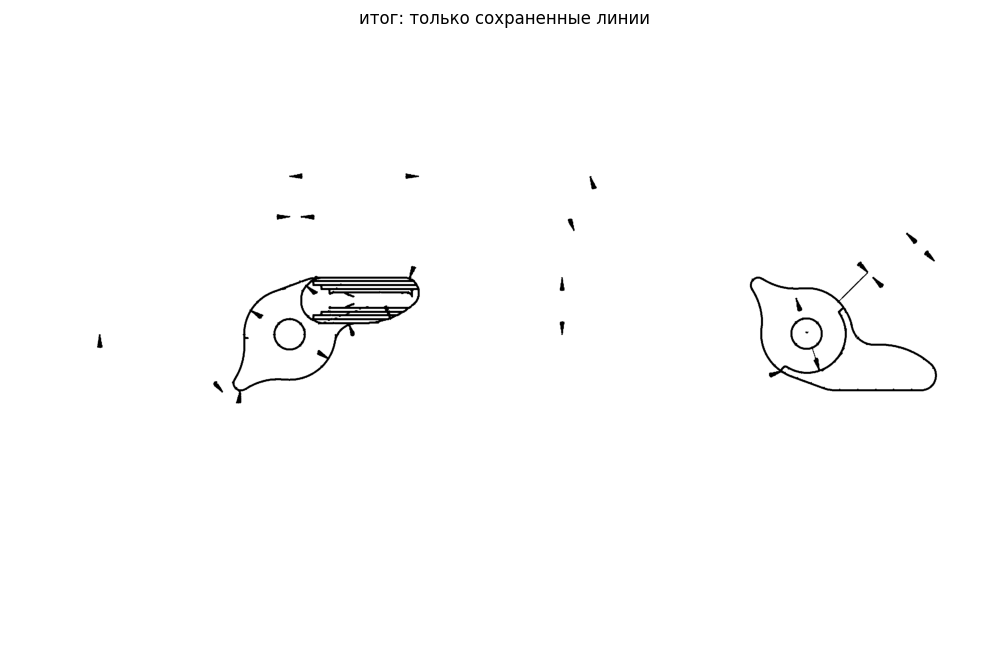

In [35]:
clean_mask: Mask = ui_clean.result
show_mask(clean_mask, "итог: только сохраненные линии")

In [36]:
def line_kernel(length: int, degrees: float) -> npt.NDArray[np.uint8]:
    """Линейный структурный элемент длиной length под углом degrees."""
    size = length + 1 - length % 2
    kernel = np.zeros((size, size), np.uint8)
    c = size // 2
    step = np.array([np.cos(np.radians(degrees)), -np.sin(np.radians(degrees))]) * c
    cv2.line(kernel, tuple(np.round(c - step).astype(int)), tuple(np.round(c + step).astype(int)), 1, 1)
    return kernel


def oriented_closing(mask: Mask, length: int, n_angles: int) -> Mask:
    """Замыкание вдоль линии: объединение closing по ориентациям. Поперек линия не растет."""
    src = mask.astype(np.uint8)
    out = np.zeros_like(src)
    for degrees in np.linspace(0.0, 180.0, n_angles, endpoint=False):
        out |= cv2.morphologyEx(src, cv2.MORPH_CLOSE, line_kernel(length, float(degrees)))
    return out > 0


In [37]:
BIG_SIDE: int = 9000  # граница разрешения исходника
CLOSE_SMALL: int = 3
CLOSE_BIG: int = 11


def closing_length(image: Img) -> int:
    """Длина ядра замыкания по разрешению исходника."""
    return CLOSE_BIG if max(image.shape[:2]) > BIG_SIDE else CLOSE_SMALL


CLOSE_LENGTH: int = closing_length(img_bgr)
print(f"исходник {img_bgr.shape[1]}x{img_bgr.shape[0]} | ядро замыкания {CLOSE_LENGTH} px")


def report_closing(before: Mask, after: Mask) -> None:
    """Сколько чернил добавлено и как изменилось число кусков."""
    was = cv2.connectedComponents(before.astype(np.uint8), connectivity=8)[0] - 1
    now = cv2.connectedComponents(after.astype(np.uint8), connectivity=8)[0] - 1
    print(
        f"добавлено {int((after & ~before).sum())} px | чернил {after.sum() / before.sum() - 1:+.1%} | кусков {was} -> {now}"
    )


def draw_closing(before: Mask, after: Mask, title: str) -> None:
    """Добавленное красным, справа результат."""
    canvas = np.full((*before.shape, 3), 255, np.uint8)
    canvas[before] = (0, 0, 0)
    canvas[after & ~before] = (0, 0, 255)

    fig, (a1, a2) = plt.subplots(1, 2, figsize=(20, 8))
    a1.imshow(canvas[..., ::-1])
    a1.set_title("красное это добавленные пиксели")
    a2.imshow(np.where(after, 0, 255).astype(np.uint8), cmap="gray")
    a2.set_title(title)
    for ax in (a1, a2):
        ax.axis("off")
    plt.show()


def run_closing(length: int, n_angles: int) -> Mask:
    """Слайдеры замыкания."""
    closed = oriented_closing(clean_mask, length, n_angles)
    report_closing(clean_mask, closed)
    draw_closing(clean_mask, closed, f"замыкание: линия {length} px, {n_angles} ориентаций")
    return closed


CLOSE_LENGTH: int = closing_length(img_bgr)
# print(f"исходник {img_bgr.shape[1]}x{img_bgr.shape[0]} | ядро замыкания {CLOSE_LENGTH} px")

ui_closing = interactive(
    run_closing,
    length=IntSlider(value=CLOSE_LENGTH, min=3, max=31, step=2, continuous_update=False, description="длина, px"),
    n_angles=IntSlider(value=8, min=2, max=16, step=2, continuous_update=False, description="ориентаций"),
)
ui_closing


исходник 1475x919 | ядро замыкания 3 px


interactive(children=(IntSlider(value=3, continuous_update=False, description='длина, px', max=31, min=3, step…

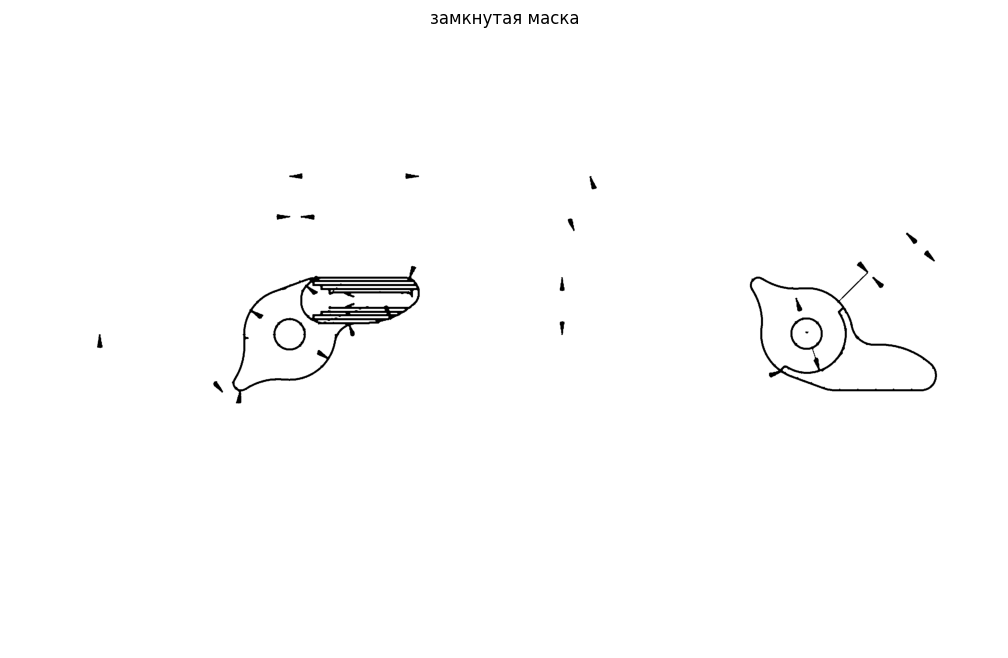

In [38]:
closed_mask: Mask = ui_closing.result
show_mask(closed_mask, "замкнутая маска")

## Приложение: трассировка осевой линии

Ветка без скелетизации: осевая идет от затравки шагами, ширина меряется поперечным сечением, трасса
рвется на скачке ширины или резком повороте. Используется для проверки того, что скелет не выдумывает
геометрию на стыках.

In [39]:
@dataclass(frozen=True)
class Chord:
    """Пробег переднего плана через точку в заданном направлении."""

    start: tuple[int, int]
    end: tuple[int, int]
    length: float


@dataclass(frozen=True)
class Seed:
    """Затравка: точка на оси, ширина и направление линии."""

    y: int
    x: int
    width: float
    dy: int
    dx: int


@dataclass(frozen=True, eq=False)
class Seeds:
    """Затравки пачкой, массивы одной длины."""

    y: Ints
    x: Ints
    width: Floats
    dy: Ints
    dx: Ints

    def __len__(self) -> int:
        return len(self.y)


DIRS: Ints = np.array([(0, 1), (1, 1), (1, 0), (1, -1)])


def chord(fg: Mask, y: int, x: int, dy: int, dx: int) -> Chord:
    """Концы и длина пробега через точку в направлении (dy, dx)."""
    h, w = fg.shape
    ends: list[tuple[int, int]] = []
    for sign in (1, -1):
        yy, xx = y, x
        while True:
            ny, nx = yy + sign * dy, xx + sign * dx
            if not (0 <= ny < h and 0 <= nx < w) or not fg[ny, nx]:
                break
            yy, xx = ny, nx
        ends.append((yy, xx))
    (y0, x0), (y1, x1) = ends
    return Chord(start=(y0, x0), end=(y1, x1), length=float(np.hypot(y1 - y0, x1 - x0) + 1))


def seed_at(fg: Mask, y: int, x: int) -> Seed:
    """Минимальная из четырех хорд дает ширину, ее середина ось, нормаль направление линии."""
    chords = [chord(fg, y, x, int(dy), int(dx)) for dy, dx in DIRS]
    i = int(np.argmin([c.length for c in chords]))
    (y0, x0), (y1, x1) = chords[i].start, chords[i].end
    dy, dx = DIRS[(i + 2) % 4]
    return Seed(y=(y0 + y1) // 2, x=(x0 + x1) // 2, width=chords[i].length, dy=int(dy), dx=int(dx))


def scan_seeds(fg: Mask, step: int) -> list[Seed]:
    """Скан каждой step-й строки: середина каждого пробега это кандидат в затравку."""
    out: list[Seed] = []
    for y in range(0, fg.shape[0], step):
        edges = np.flatnonzero(np.diff(np.r_[0, fg[y].astype(np.int8), 0]))
        for x0, x1 in edges.reshape(-1, 2):
            out.append(seed_at(fg, y, (x0 + x1 - 1) // 2))
    return out


def build_seeds(fg: Mask, step: int) -> Seeds:
    """Скан по строкам и по столбцам: горизонтали ловит второй проход, вертикали первый."""
    rows = scan_seeds(fg, step)
    cols = [Seed(y=s.x, x=s.y, width=s.width, dy=s.dx, dx=s.dy) for s in scan_seeds(np.ascontiguousarray(fg.T), step)]
    every = rows + cols
    print(f"затравок {len(every)}: по строкам {len(rows)}, по столбцам {len(cols)}")
    return Seeds(
        y=np.array([s.y for s in every], dtype=np.int64),
        x=np.array([s.x for s in every], dtype=np.int64),
        width=np.array([s.width for s in every], dtype=np.float64),
        dy=np.array([s.dy for s in every], dtype=np.int64),
        dx=np.array([s.dx for s in every], dtype=np.int64),
    )

источник трассировки: чернил 0.90% кадра | у исходных штрихов 2.82%


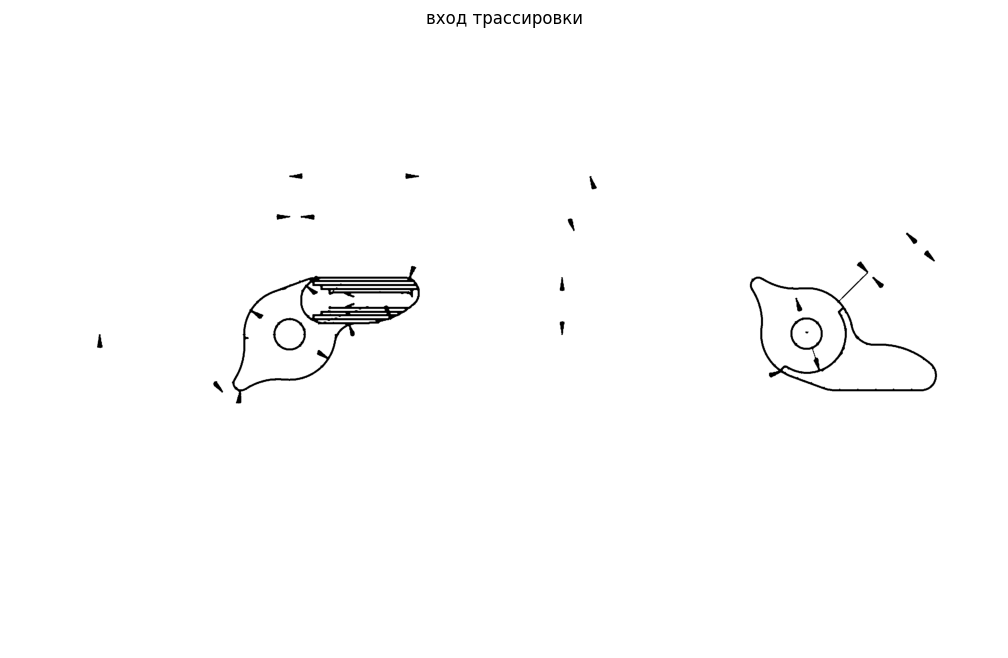

In [40]:
trace_fg: Mask = closed_mask
print(
    f"источник трассировки: чернил {trace_fg.mean() * 100:.2f}% кадра | у исходных штрихов {strokes.fg.mean() * 100:.2f}%"
)
show_mask(trace_fg, "вход трассировки")


In [41]:
clean_strokes: Strokes = Strokes(
    gray=strokes.gray,
    binary=np.where(closed_mask, 255, 0).astype(np.uint8),
    fg=closed_mask,
)
clean_graph: StrokeGraph = build_graph(clean_strokes, text_region)

report_graph(clean_graph)


путей 102 | пикселей оси 6993
ребер 102 | медиана толщины 7.0 px
                       n  len_sum  len_share  n_short  n_text
конец-конец (изолят)  11    386.0      0.051        1       0
узел-конец (шпора)    30    516.0      0.068       18       0
узел-узел             59   6086.0      0.802       16       0
цикл                   2    602.0      0.079        0       0
узлов 103 | концов 52 | deg=2 1 | стыков 50
текстовых ребер 0 (0.0%)


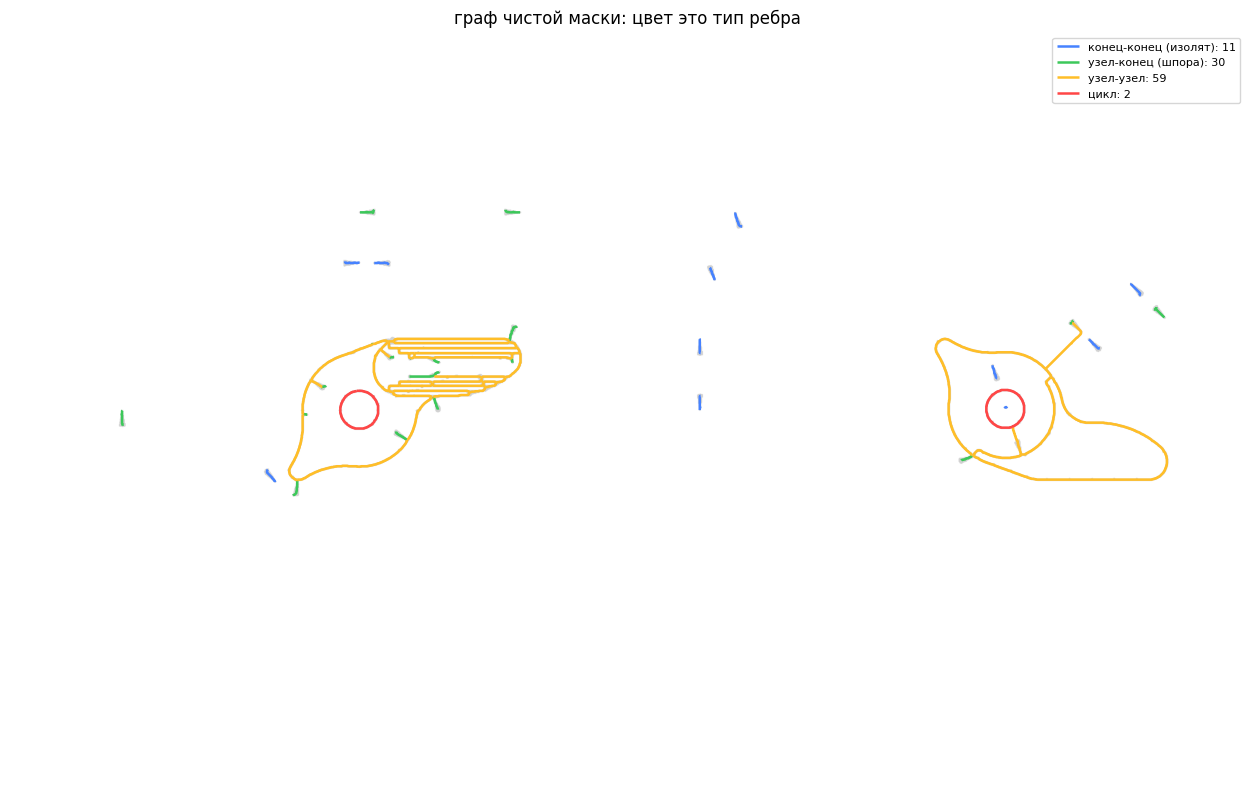

In [42]:
def draw_branch_types(graph: StrokeGraph, mask: Mask, title: str) -> None:
    """Цвет ребра это тип ветвления: висячие обрубки отделяются от контура детали."""
    palette = np.array(PALETTE[: len(BRANCH_NAMES)], dtype=float) / 255
    fig, ax = plt.subplots(figsize=(18, 10))
    ax.imshow(np.where(mask, 210, 255).astype(np.uint8), cmap="gray", vmin=0, vmax=255)
    for kind, name in BRANCH_NAMES.items():
        sel = np.flatnonzero(graph.branch == kind)
        ax.add_collection(
            LineCollection(
                [graph.xy(i) for i in sel],
                colors=palette[kind],
                linewidths=1.8,
                label=f"{name}: {len(sel)}",
            )
        )
    ax.axis("off")
    ax.set_title(title)
    ax.legend(loc="upper right", fontsize=8)
    plt.show()


draw_branch_types(clean_graph, closed_mask, "граф чистой маски: цвет это тип ребра")


In [43]:
@dataclass(frozen=True, eq=False)
class TextInside:
    """Внутренность замкнутых компонент и доля текста в ней."""

    component: Ints
    share: Floats
    area: Ints


def fill_holes(mask: Mask) -> Mask:
    """Заливка внутренних пустот: фон, недостижимый от края кадра."""
    padded = np.zeros((mask.shape[0] + 2, mask.shape[1] + 2), np.uint8)
    padded[1:-1, 1:-1] = mask.astype(np.uint8) * 255
    cv2.floodFill(padded, np.zeros((padded.shape[0] + 2, padded.shape[1] + 2), np.uint8), (0, 0), 255)
    return mask | (padded[1:-1, 1:-1] == 0)


def component_axes(graph: StrokeGraph, keep: Mask, component: Ints) -> Ints:
    """Карта пикселей: id компоненты на осях сохраненных ребер, -1 вне."""
    out = np.full(graph.pid.shape, -1, dtype=np.int64)
    on = (graph.pid >= 0) & keep[np.maximum(graph.pid, 0)]
    out[on] = component[graph.pid[on]]
    return out


def text_inside(axes: Ints, text_region: Mask) -> TextInside:
    """Для каждой замкнутой компоненты доля ее внутренней площади, занятая текстом."""
    ys, xs = np.nonzero(axes >= 0)
    if not len(ys):
        return TextInside(np.zeros(0, np.int64), np.zeros(0), np.zeros(0, np.int64))

    comp = axes[ys, xs]
    order = np.argsort(comp, kind="stable")
    ids: list[int] = []
    share: list[float] = []
    area: list[int] = []
    for group in np.split(order, np.flatnonzero(np.diff(comp[order])) + 1):
        y0, y1 = int(ys[group].min()), int(ys[group].max()) + 1
        x0, x1 = int(xs[group].min()), int(xs[group].max()) + 1
        sub = np.zeros((y1 - y0, x1 - x0), dtype=bool)
        sub[ys[group] - y0, xs[group] - x0] = True
        inside = fill_holes(sub) & ~sub
        if not inside.any():
            continue
        ids.append(int(comp[group[0]]))
        area.append(int(inside.sum()))
        share.append(float(text_region[y0:y1, x0:x1][inside].mean()))
    return TextInside(np.array(ids, dtype=np.int64), np.array(share), np.array(area, dtype=np.int64))


In [44]:
@dataclass(frozen=True)
class Shape:
    """Пиксельные признаки одной компоненты."""

    component: int
    diameter: float  # диагональ габарита
    t_med: float  # медиана толщины по пикселям оси
    t_spread: float  # p90 / p10 толщины: у клина большой, у линии около 1
    inside: int  # внутренняя площадь, px
    text_inside: float  # доля этой площади под текстом


@dataclass(frozen=True, eq=False)
class Passport:
    """Признаки связных компонент. Массивы одной длины, кроме edge и twig."""

    edge: Ints  # ребро -> компонента, длина n_paths
    twig: Mask  # ребро висячее, длина n_paths
    component: Ints
    edges: Ints
    length: Floats  # суммарная длина осей
    diameter: Floats
    tortuosity: Floats  # длина / габарит
    t_med: Floats
    t_spread: Floats
    inside: Ints
    text_inside: Floats
    twigs: Ints  # висячих ребер в компоненте
    twig_share: Floats  # доля длины компоненты, висящая хвостами
    twig_max: Floats  # длина самого длинного хвоста
    twig_spread: Floats  # максимальный p90/p10 среди хвостов

    def __len__(self) -> int:
        return len(self.component)


def hanging_paths(graph: StrokeGraph, keep: Mask) -> Mask:
    """Ребра с висячим концом среди сохраненных."""
    n = len(graph.skeleton.coordinates)
    degree = np.bincount(np.concatenate([graph.src[keep], graph.dst[keep]]), minlength=n)
    return keep & (graph.src != graph.dst) & ((degree[graph.src] == 1) | (degree[graph.dst] == 1))


def path_spread(graph: StrokeGraph, paths: Ints) -> Floats:
    """Отношение p90/p10 толщины вдоль оси ребра. Не перечисленные -> nan."""
    out = np.full(graph.n_paths, np.nan)
    for i in paths:
        rc = graph.skeleton.path_coordinates(i).astype(int)
        low, high = np.percentile(2 * graph.dist[rc[:, 0], rc[:, 1]] - 1, [10, 90])
        out[i] = high / max(low, 1e-6)
    return out


def component_shape(cid: int, ys: Ints, xs: Ints, dist: Floats, text_region: Mask) -> Shape:
    """Габарит, толщина и внутренность компоненты, посчитанные в ее bbox."""
    y0, y1 = int(ys.min()), int(ys.max()) + 1
    x0, x1 = int(xs.min()), int(xs.max()) + 1
    sub = np.zeros((y1 - y0, x1 - x0), dtype=bool)
    sub[ys - y0, xs - x0] = True
    hole = fill_holes(sub) & ~sub
    low, mid, high = np.percentile(2 * dist[ys, xs] - 1, [10, 50, 90])
    return Shape(
        component=cid,
        diameter=float(np.hypot(y1 - y0, x1 - x0)),
        t_med=float(mid),
        t_spread=float(high / max(low, 1e-6)),
        inside=int(hole.sum()),
        text_inside=float(text_region[y0:y1, x0:x1][hole].mean()) if hole.any() else 0.0,
    )


def link_components(graph: StrokeGraph, alive: Mask) -> Ints:
    """Связная компонента для каждого ребра, считается по узлам живых ребер."""
    n = len(graph.skeleton.coordinates)
    g = coo_matrix((np.ones(int(alive.sum())), (graph.src[alive], graph.dst[alive])), shape=(n, n))
    return connected_components(g, directed=False)[1][graph.src]


def build_passport(graph: StrokeGraph, text_region: Mask) -> Passport:
    """Паспорт каждой связной компоненты графа, включая ее хвосты."""
    every = np.ones(graph.n_paths, dtype=bool)
    edge = link_components(graph, every)
    count = int(edge.max()) + 1
    twig = hanging_paths(graph, every)
    spread = path_spread(graph, np.flatnonzero(twig))

    edges = np.bincount(edge, minlength=count)
    length = np.bincount(edge, weights=graph.length, minlength=count)
    twigs = np.bincount(edge[twig], minlength=count)
    twig_len = np.bincount(edge, weights=graph.length * twig, minlength=count)
    twig_max = np.zeros(count)
    twig_spread = np.zeros(count)
    np.maximum.at(twig_max, edge[twig], graph.length[twig])
    np.maximum.at(twig_spread, edge[twig], spread[twig])

    axes = component_axes(graph, every, edge)
    ys, xs = np.nonzero(axes >= 0)
    comp = axes[ys, xs]
    order = np.argsort(comp, kind="stable")
    shapes = [
        component_shape(int(comp[g[0]]), ys[g], xs[g], graph.dist, text_region)
        for g in np.split(order, np.flatnonzero(np.diff(comp[order])) + 1)
    ]

    idx = np.array([s.component for s in shapes], dtype=np.int64)
    diameter = np.array([s.diameter for s in shapes])
    print(f"компонент {len(shapes)} | ребер {graph.n_paths} | висячих {int(twig.sum())}")
    return Passport(
        edge=edge,
        twig=twig,
        component=idx,
        edges=edges[idx],
        length=length[idx],
        diameter=diameter,
        tortuosity=length[idx] / np.maximum(diameter, 1.0),
        t_med=np.array([s.t_med for s in shapes]),
        t_spread=np.array([s.t_spread for s in shapes]),
        inside=np.array([s.inside for s in shapes], dtype=np.int64),
        text_inside=np.array([s.text_inside for s in shapes]),
        twigs=twigs[idx],
        twig_share=twig_len[idx] / np.maximum(length[idx], 1.0),
        twig_max=twig_max[idx],
        twig_spread=twig_spread[idx],
    )


In [45]:
def report_passport(passport: Passport, top: int = 20) -> None:
    """Паспорт в виде таблицы. DataFrame нужен только для печати."""
    table = pd.DataFrame(
        {
            "id": passport.component,
            "ребер": passport.edges,
            "длина": passport.length.round(0),
            "габарит": passport.diameter.round(0),
            "извил": passport.tortuosity.round(2),
            "t": passport.t_med.round(1),
            "t p90/p10": passport.t_spread.round(2),
            "внутри": passport.inside,
            "текст": passport.text_inside.round(2),
            "хвостов": passport.twigs,
            "хвост доля": passport.twig_share.round(2),
            "хвост max": passport.twig_max.round(0),
            "хвост t": passport.twig_spread.round(2),
        }
    ).sort_values("длина", ascending=False)
    small = passport.length < 50
    print(
        f"компонент {len(passport)} | короче 50 px: {int(small.sum())} штук, {passport.length[small].sum() / passport.length.sum():.1%} длины"
    )
    print(table.head(top).to_string(index=False))


def draw_passport(graph: StrokeGraph, passport: Passport, win: Window, min_label: float, title: str) -> None:
    """Цвет это компонента, хвосты пунктиром, подписаны только крупные."""
    ax = ax_view(win, title)
    colors = plt.cm.hsv(np.random.default_rng(2).permutation(len(passport)) / max(len(passport) - 1, 1))
    rank = np.zeros(int(passport.edge.max()) + 1, dtype=np.int64)
    rank[passport.component] = np.arange(len(passport))
    ax.add_collection(
        LineCollection([graph.xy(i) for i in range(graph.n_paths)], colors=colors[rank[passport.edge]], linewidths=1.8)
    )
    ax.add_collection(
        LineCollection(
            [graph.xy(i) for i in np.flatnonzero(passport.twig)],
            colors="black",
            linewidths=0.9,
            linestyles="dashed",
            zorder=5,
        )
    )
    for cid, length in zip(passport.component, passport.length, strict=True):
        if length < min_label:
            continue
        sel = np.flatnonzero(passport.edge == cid)
        x, y = graph.xy(int(sel[0]))[0]
        ax.text(x, y, str(int(cid)), fontsize=9, color="black", ha="center", va="center")
    plt.show()


def run_passport(cx: float, cy: float, zoom: float, min_label: float) -> Passport:
    """Слайдеры просмотра паспорта."""
    passport = build_passport(clean_graph, text_region)
    report_passport(passport)
    draw_passport(
        clean_graph,
        passport,
        view_window(cx, cy, zoom),
        min_label,
        "компоненты: цвет это компонента, пунктир это хвост",
    )
    return passport


ui_passport = interactive(
    run_passport,
    **view_sliders(),
    min_label=FloatSlider(
        value=100.0, min=0.0, max=1000.0, step=50.0, continuous_update=False, description="подпись от, px"
    ),
)
ui_passport


interactive(children=(FloatSlider(value=0.5, continuous_update=False, description='центр X', max=1.0, step=0.0…

In [46]:
@dataclass(frozen=True)
class KeepParams:
    """Пороги правила выживания компоненты."""

    min_inside: int = 1000  # внутренняя площадь, px
    max_spread: float = 2.5  # p90/p10 толщины: выше это клин
    min_winding: float = 1.6  # извилистость для незамкнутых
    text_limit: float = 0.10  # доля внутренней площади под текстом


def keep_components(passport: Passport, params: KeepParams) -> Mask:
    """Живет замкнутое, либо ровное по толщине и извилистое. Текст внутри убивает в любом случае."""
    closed = passport.inside >= params.min_inside
    ridge = (passport.t_spread <= params.max_spread) & (passport.tortuosity >= params.min_winding)
    return (closed | ridge) & (passport.text_inside < params.text_limit)


def paths_of(passport: Passport, keep: Mask) -> Mask:
    """Решение по компонентам -> маска ребер."""
    lut = np.zeros(int(passport.edge.max()) + 1, dtype=bool)
    lut[passport.component] = keep
    return lut[passport.edge]


def report_keep(passport: Passport, keep: Mask) -> None:
    """Кто выжил и почему. DataFrame нужен только для печати."""
    table = pd.DataFrame(
        {
            "id": passport.component,
            "длина": passport.length.round(0),
            "извил": passport.tortuosity.round(2),
            "t p90/p10": passport.t_spread.round(2),
            "внутри": passport.inside,
            "текст": passport.text_inside.round(2),
            "живет": keep,
        }
    ).sort_values("длина", ascending=False)
    print(
        f"компонент {len(passport)} | выжило {int(keep.sum())} | длины {passport.length[keep].sum() / passport.length.sum():.1%}"
    )
    print(table.head(15).to_string(index=False))


def draw_keep(graph: StrokeGraph, passport: Passport, keep: Mask, win: Window, title: str) -> None:
    """Зеленое выжило, красное убрано."""
    alive = paths_of(passport, keep)
    ax = ax_view(win, title)
    for sel, color, zorder in ((alive, "green", 3), (~alive, "red", 4)):
        ax.add_collection(
            LineCollection([graph.xy(i) for i in np.flatnonzero(sel)], colors=color, linewidths=1.8, zorder=zorder)
        )
    plt.show()


def run_keep(cx: float, cy: float, zoom: float, min_inside: int, max_spread: float, min_winding: float) -> Mask:
    """Слайдеры правила."""
    params = KeepParams(min_inside=min_inside, max_spread=max_spread, min_winding=min_winding)
    keep = keep_components(passport, params)
    report_keep(passport, keep)
    draw_keep(
        clean_graph,
        passport,
        keep,
        view_window(cx, cy, zoom),
        f"правило: внутри >= {min_inside}, t p90/p10 <= {max_spread:.1f}, извил >= {min_winding:.2f}",
    )
    return keep


passport: Passport = ui_passport.result
ui_keep = interactive(
    run_keep,
    **view_sliders(),
    min_inside=IntSlider(value=1000, min=0, max=20000, step=500, continuous_update=False, description="внутри >="),
    max_spread=FloatSlider(value=2.5, min=1.1, max=6.0, step=0.1, continuous_update=False, description="t p90/p10 <="),
    min_winding=FloatSlider(value=1.6, min=1.0, max=3.0, step=0.05, continuous_update=False, description="извил >="),
)
ui_keep


interactive(children=(FloatSlider(value=0.5, continuous_update=False, description='центр X', max=1.0, step=0.0…

In [50]:
TWIG_SHARE: float = 0.01  # хвост короче этой доли своей компоненты срезается
REPEAT_TOL: float = 0.05  # относительный допуск на совпадение размеров
MIN_REPEAT: int = 3  # столько одинаковых, чтобы счесть шаблоном


def trim_twigs(graph: StrokeGraph, keep: Mask, edge: Ints, share: float) -> Mask:
    """Хвост короче доли своей компоненты срезается. Итеративно, пока есть что резать."""
    count = int(edge.max()) + 1
    keep = keep.copy()
    while True:
        length = np.bincount(edge, weights=graph.length * keep, minlength=count)
        cut = hanging_paths(graph, keep) & (graph.length < share * length[edge])
        if not cut.any():
            return keep
        keep &= ~cut


def repeat_groups(passport: Passport, tol: float) -> Ints:
    """Метка группы похожих компонент: размеры с относительным допуском."""
    feature = np.stack(
        [
            np.log(np.maximum(passport.length, 1.0)),
            np.log(np.maximum(passport.diameter, 1.0)),
            np.log(np.maximum(passport.tortuosity, 1.0)),
        ],
        axis=1,
    )
    close = np.abs(feature[:, None, :] - feature[None, :, :]).max(axis=2) <= tol
    return connected_components(coo_matrix(close), directed=False)[1]


def repeated_trash(passport: Passport, group: Ints, min_repeat: int) -> Mask:
    """Незамкнутые компоненты, встречающиеся min_repeat раз и чаще."""
    return (np.bincount(group)[group] >= min_repeat) & (passport.inside == 0)


def report_trim(graph: StrokeGraph, before: Mask, after: Mask) -> None:
    """Сколько срезано и что из висячего уцелело."""
    cut = before & ~after
    print(
        f"срезано хвостов {int(cut.sum())} | длина {graph.length[cut].sum():.0f} px ({graph.length[cut].sum() / max(graph.length[before].sum(), 1):.1%})"
    )
    alive = hanging_paths(graph, after)
    print(f"осталось висячих {int(alive.sum())} | длиннее 100 px: {int((alive & (graph.length > 100)).sum())}")


def draw_trim(graph: StrokeGraph, dropped: Mask, trimmed: Mask, final: Mask, win: Window, title: str) -> None:
    """Зеленое финал, красное убрано правилом компонент, оранжевое срезанные хвосты."""
    ax = ax_view(win, title)
    for sel, color, zorder in ((final, "green", 3), (dropped, "red", 4), (trimmed, "orange", 5)):
        ax.add_collection(
            LineCollection([graph.xy(i) for i in np.flatnonzero(sel)], colors=color, linewidths=1.8, zorder=zorder)
        )
    plt.show()


In [51]:
def report_final(passport: Passport, group: Ints, repeated: Mask, graph: StrokeGraph, alive: Mask, final: Mask) -> None:
    """Группы повторов и итог обрезки. DataFrame нужен только для печати."""
    table = pd.DataFrame(
        {
            "группа": group,
            "id": passport.component,
            "длина": passport.length.round(0),
            "габарит": passport.diameter.round(0),
            "извил": passport.tortuosity.round(2),
            "повтор": repeated,
        }
    )
    sizes = table.groupby("группа").agg(штук=("id", "size"), длина=("длина", "median"), повтор=("повтор", "first"))
    print(f"групп {len(sizes)} | шаблонных компонент {int(repeated.sum())} из {len(passport)}")
    print(sizes.sort_values("штук", ascending=False).head(8).to_string())

    cut = alive & ~final
    print(f"\nсрезано хвостов {int(cut.sum())} | длина {graph.length[cut].sum():.0f} px")
    print(f"осталось ребер {int(final.sum())} | длины {graph.length[final].sum() / graph.length.sum():.1%}")


def run_final(cx: float, cy: float, zoom: float) -> Mask:
    """Правило паспорта, минус повторы, минус хвосты."""
    group = repeat_groups(passport, REPEAT_TOL)
    repeated = repeated_trash(passport, group, MIN_REPEAT)
    alive = paths_of(passport, ui_keep.result & ~repeated)
    final = trim_twigs(clean_graph, alive, passport.edge, TWIG_SHARE)
    report_final(passport, group, repeated, clean_graph, alive, final)
    draw_trim(clean_graph, ~alive, alive & ~final, final, view_window(cx, cy, zoom), "итог: паспорт, повторы, хвосты")
    return final


ui_final = interactive(run_final, **view_sliders())
ui_final


interactive(children=(FloatSlider(value=0.5, continuous_update=False, description='центр X', max=1.0, step=0.0…

ребер 62 из 102 | чернил 26.8% от оригинала | компонент 3


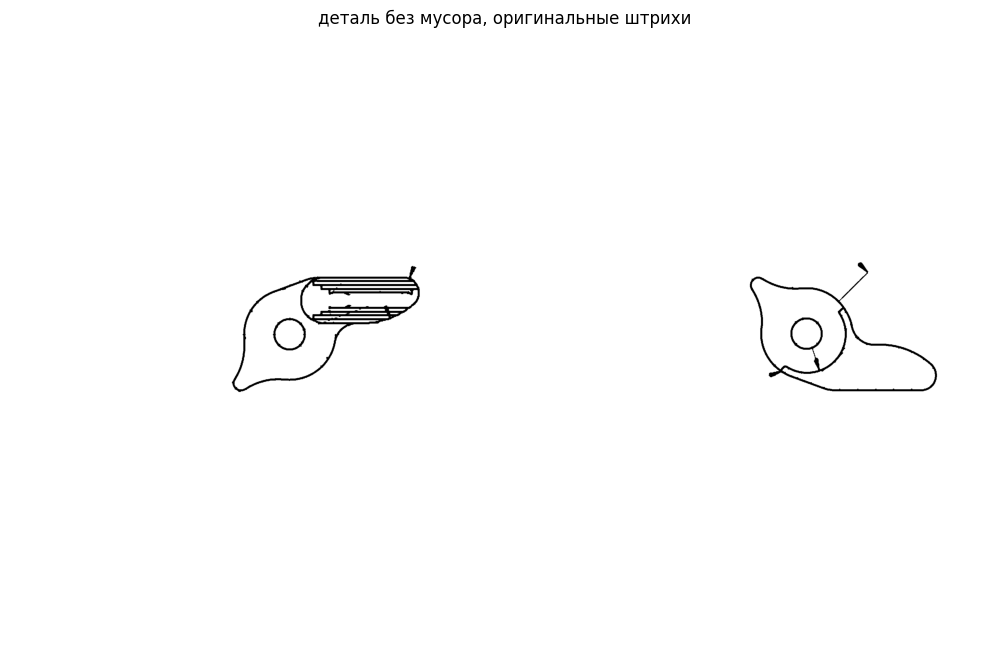

In [49]:
final_paths: Mask = ui_final.result
part_mask: Mask = paint_paths(clean_graph, final_paths, strokes.fg, tol=0.5)

components = cv2.connectedComponents(part_mask.astype(np.uint8), connectivity=8)[0] - 1
print(
    f"ребер {int(final_paths.sum())} из {clean_graph.n_paths} | чернил {part_mask.sum() / strokes.fg.sum():.1%} от оригинала | компонент {components}"
)
show_mask(part_mask, "деталь без мусора, оригинальные штрихи")
